## Nama: wirdana
## nim: 4222301031
## kelas: B_pagi



## 0. Install & Import Library

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import hog
from skimage import exposure

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

# Set random seed untuk reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('berhasil')

berhasil


## 1. Load Dataset


In [19]:
TRAIN_PATH = 'emnist-letters-train.csv'
TEST_PATH  = 'emnist-letters-test.csv'   

df_train = pd.read_csv(TRAIN_PATH, header=None)
df_test  = pd.read_csv(TEST_PATH,  header=None)

print(f'Train shape : {df_train.shape}')
print(f'Test shape  : {df_test.shape}')
print(f'Jumlah kelas: {df_train[0].nunique()} (label 1-26 → A-Z)')

Train shape : (88800, 785)
Test shape  : (14800, 785)
Jumlah kelas: 26 (label 1-26 → A-Z)


In [20]:
SAMPLES_PER_CLASS = 100
NUM_CLASSES = 26
TOTAL_SAMPLES = SAMPLES_PER_CLASS * NUM_CLASSES  # 2600

# Gabungkan semua data
df_all = pd.concat([df_train, df_test], ignore_index=True)

# Shuffle dulu sebelum sampling
df_all = df_all.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

# Ambil 100 sampel per kelas (balanced)
df_sampled = (
    df_all.groupby(0, group_keys=False)
          .apply(lambda x: x.sample(SAMPLES_PER_CLASS, random_state=RANDOM_SEED))
          .reset_index(drop=True)
)

# Shuffle lagi setelah sampling
df_sampled = df_sampled.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

print(f'Dataset setelah sampling: {df_sampled.shape}')
print(f'Distribusi kelas (harus 100 tiap kelas):')
print(df_sampled[0].value_counts().sort_index())

Dataset setelah sampling: (2600, 785)
Distribusi kelas (harus 100 tiap kelas):
0
1     100
2     100
3     100
4     100
5     100
6     100
7     100
8     100
9     100
10    100
11    100
12    100
13    100
14    100
15    100
16    100
17    100
18    100
19    100
20    100
21    100
22    100
23    100
24    100
25    100
26    100
Name: count, dtype: int64


In [ ]:
X_raw = df_sampled.iloc[:, 1:].values.astype(np.float32)  # pixel values
y_raw = df_sampled.iloc[:, 0].values                       # label 1-26

# Konversi label angka (1-26) → huruf (A-Z)
label_map = {i: chr(64 + i) for i in range(1, 27)}  # 1→A, 2→B, ..., 26→Z
y_labels  = np.array([label_map[l] for l in y_raw])

# Reshape pixel → gambar 28×28
X_images = X_raw.reshape(-1, 28, 28)

print(f'X_images shape : {X_images.shape}')
print(f'y_labels sample: {y_labels[:10]}')

X_images shape : (2600, 28, 28)
y_labels sample: ['P' 'B' 'C' 'V' 'P' 'T' 'Q' 'E' 'H' 'U']


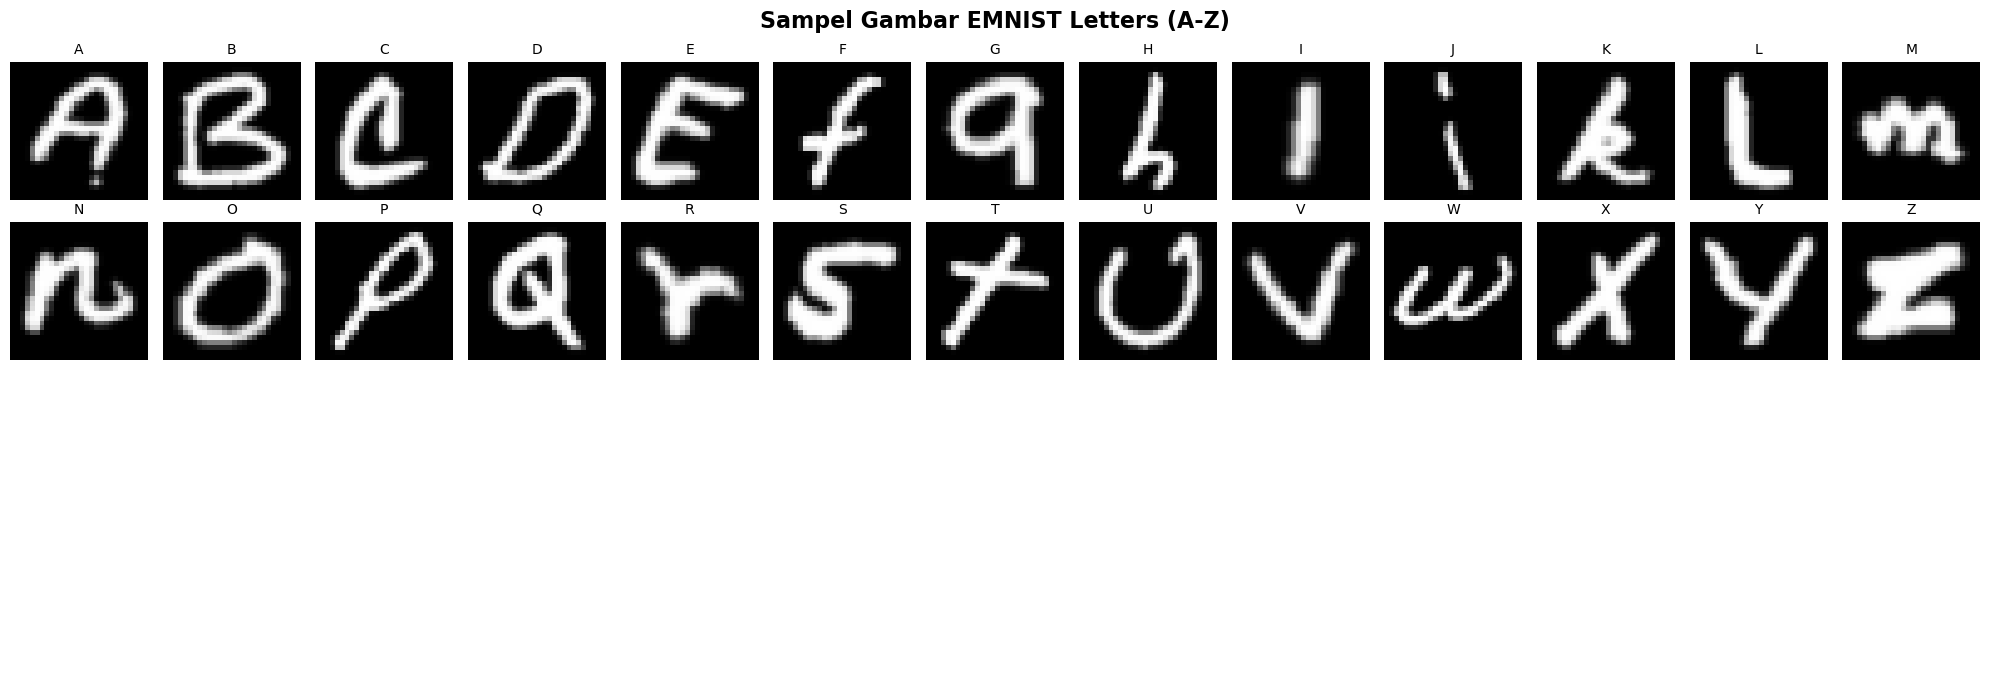

Visualisasi sampel disimpan: sample_images.png


In [ ]:
fig, axes = plt.subplots(4, 13, figsize=(20, 7))
fig.suptitle('Sampel Gambar EMNIST Letters (A-Z)', fontsize=16, fontweight='bold')

for i, letter in enumerate(sorted(set(y_labels))):
    idx = np.where(y_labels == letter)[0][0]
    ax  = axes[i // 13][i % 13]
    
    # EMNIST perlu di-transpose & flip untuk orientasi benar
    img = np.transpose(X_images[idx])
    ax.imshow(img, cmap='gray')
    ax.set_title(letter, fontsize=10)
    ax.axis('off')

# Sembunyikan subplot yang tidak terpakai (13*4=52, kita punya 26)
for j in range(26, 52):
    axes[j // 13][j % 13].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi sampel disimpan: sample_images.png')

In [ ]:
from sklearn.model_selection import train_test_split

X_train_img, X_test_img, y_train, y_test = train_test_split(
    X_images, y_labels,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y_labels  
)

print(f'Train: {X_train_img.shape[0]} sampel ({X_train_img.shape[0]/TOTAL_SAMPLES*100:.0f}%)')
print(f'Test : {X_test_img.shape[0]}  sampel ({X_test_img.shape[0]/TOTAL_SAMPLES*100:.0f}%)')

Train: 2080 sampel (80%)
Test : 520  sampel (20%)


## 2. HOG Feature Extraction



In [ ]:
def extract_hog_features(images, orientations=9, pixels_per_cell=(4,4), cells_per_block=(2,2)):
    features = []
    for img in images:
        img_T = np.transpose(img)  # koreksi orientasi EMNIST
        fd = hog(
            img_T,
            orientations=orientations,
            pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block,
            block_norm='L2-Hys',
            visualize=False
        )
        features.append(fd)
    return np.array(features)

# Parameter HOG yang digunakan 
HOG_PARAMS = {
    'orientations'   : 9,      
    'pixels_per_cell': (4, 4), 
    'cells_per_block': (2, 2)  
}

print('Ekstraksi fitur HOG...')
X_train_hog = extract_hog_features(X_train_img, **HOG_PARAMS)
X_test_hog  = extract_hog_features(X_test_img,  **HOG_PARAMS)

print(f'HOG features train : {X_train_hog.shape}')
print(f'HOG features test  : {X_test_hog.shape}')
print(f'Dimensi fitur per gambar: {X_train_hog.shape[1]}')

Ekstraksi fitur HOG...
HOG features train : (2080, 1296)
HOG features test  : (520, 1296)
Dimensi fitur per gambar: 1296


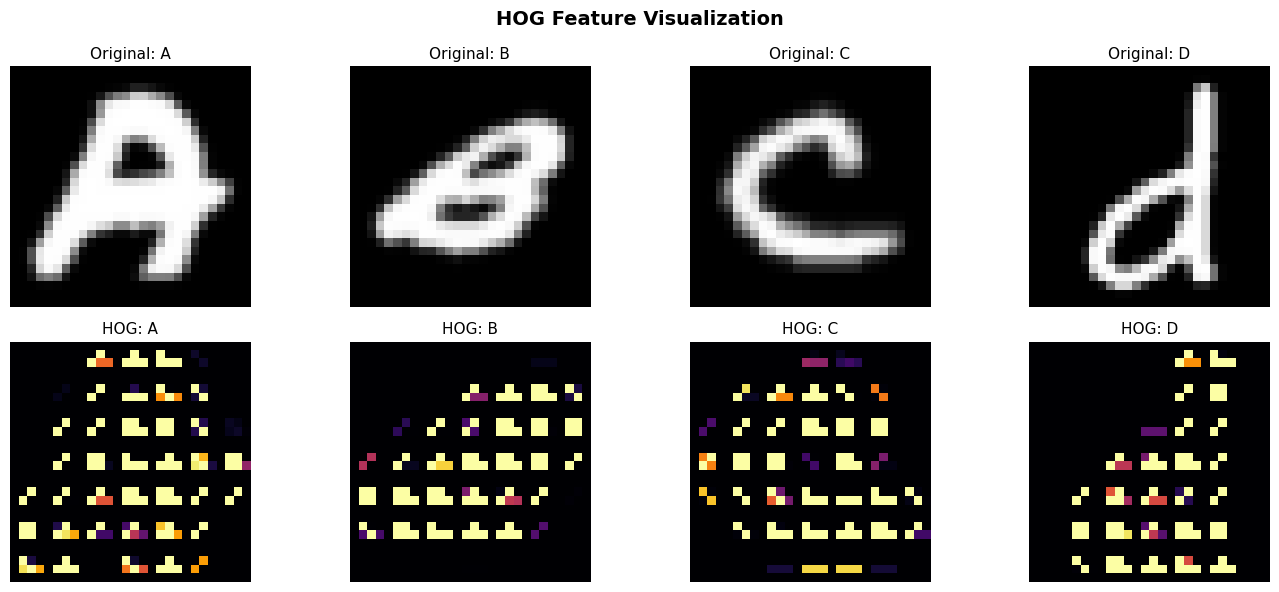

HOG visualization disimpan: hog_visualization.png


In [ ]:
sample_letters = ['A', 'B', 'C', 'D']

fig, axes = plt.subplots(2, len(sample_letters), figsize=(14, 6))
fig.suptitle('HOG Feature Visualization', fontsize=14, fontweight='bold')

for col, letter in enumerate(sample_letters):
    idx = np.where(y_train == letter)[0][0]
    img_T = np.transpose(X_train_img[idx])
    
    # Hitung HOG dengan visualisasi
    fd, hog_img = hog(
        img_T,
        orientations=HOG_PARAMS['orientations'],
        pixels_per_cell=HOG_PARAMS['pixels_per_cell'],
        cells_per_block=HOG_PARAMS['cells_per_block'],
        block_norm='L2-Hys',
        visualize=True
    )
    hog_img_rescaled = exposure.rescale_intensity(hog_img, in_range=(0, 10))
    
    axes[0][col].imshow(img_T, cmap='gray')
    axes[0][col].set_title(f'Original: {letter}', fontsize=11)
    axes[0][col].axis('off')
    
    axes[1][col].imshow(hog_img_rescaled, cmap='inferno')
    axes[1][col].set_title(f'HOG: {letter}', fontsize=11)
    axes[1][col].axis('off')

plt.tight_layout()
plt.savefig('hog_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('HOG visualization disimpan: hog_visualization.png')

## 3. Classification dengan SVM + Grid Search

**Support Vector Machine (SVM)** mencari hyperplane terbaik yang memisahkan kelas.

Parameter yang di-tune:
- `kernel`: fungsi transformasi (linear / rbf / poly)
- `C`: regularisasi (makin besar → makin fleksibel, risiko overfit)
- `gamma`: pengaruh tiap data point (untuk kernel rbf/poly)

In [27]:
# ============================================================
# 3.1 Grid Search untuk menemukan parameter SVM terbaik
# ============================================================
param_grid = {
    'kernel': ['rbf', 'linear'],
    'C'     : [0.1, 1, 10],
    'gamma' : ['scale', 'auto']   # hanya berlaku untuk kernel non-linear
}

print(' Menjalankan Grid Search... (ini mungkin perlu beberapa menit)')
print(f'   Total kombinasi: {2*3*2} = 12 kombinasi × 5-fold CV = 60 model')

svm_base = SVC(random_state=RANDOM_SEED, probability=True)

grid_search = GridSearchCV(
    estimator=svm_base,
    param_grid=param_grid,
    cv=5,               # 5-fold cross validation
    scoring='accuracy',
    n_jobs=-1,          # pakai semua CPU core
    verbose=1
)

grid_search.fit(X_train_hog, y_train)

print(f'\n Grid Search selesai!')
print(f'Parameter terbaik : {grid_search.best_params_}')
print(f'Akurasi CV terbaik: {grid_search.best_score_:.4f} ({grid_search.best_score_*100:.2f}%)')

 Menjalankan Grid Search... (ini mungkin perlu beberapa menit)
   Total kombinasi: 12 = 12 kombinasi × 5-fold CV = 60 model
Fitting 5 folds for each of 12 candidates, totalling 60 fits

 Grid Search selesai!
Parameter terbaik : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Akurasi CV terbaik: 0.8192 (81.92%)


Top 5 kombinasi parameter:
param_kernel  param_C param_gamma  mean_test_score  std_test_score
         rbf     10.0       scale         0.819231        0.022876
      linear      0.1       scale         0.816346        0.024115
      linear      0.1        auto         0.816346        0.024115
      linear     10.0       scale         0.813462        0.024115
      linear     10.0        auto         0.813462        0.024115


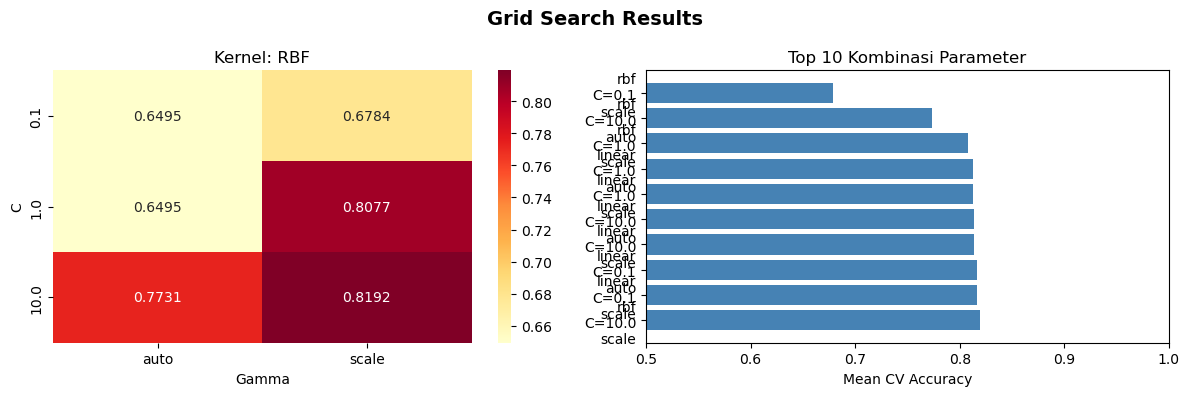

In [28]:
# ============================================================
# 3.2 Visualisasi hasil Grid Search
# ============================================================
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df.sort_values('mean_test_score', ascending=False)

print('Top 5 kombinasi parameter:')
print(results_df[['param_kernel','param_C','param_gamma','mean_test_score','std_test_score']]
      .head(5)
      .to_string(index=False))

# Plot heatmap akurasi GridSearch (kernel rbf)
pivot_rbf = results_df[results_df['param_kernel']=='rbf'].pivot_table(
    index='param_C', columns='param_gamma', values='mean_test_score'
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Grid Search Results', fontsize=14, fontweight='bold')

# Heatmap RBF
sns.heatmap(pivot_rbf, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax1)
ax1.set_title('Kernel: RBF')
ax1.set_xlabel('Gamma')
ax1.set_ylabel('C')

# Bar plot top hasil
top10 = results_df.head(10).copy()
top10['label'] = top10.apply(
    lambda r: f"{r['param_kernel']}\nC={r['param_C']}\n{r['param_gamma']}", axis=1
)
ax2.barh(top10['label'], top10['mean_test_score'], color='steelblue')
ax2.set_xlabel('Mean CV Accuracy')
ax2.set_title('Top 10 Kombinasi Parameter')
ax2.set_xlim(0.5, 1.0)

plt.tight_layout()
plt.savefig('gridsearch_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# ============================================================
# 3.3 Latih model SVM terbaik & ukur training performance
# ============================================================
best_svm = grid_search.best_estimator_

# Prediksi pada data TRAINING
y_train_pred = best_svm.predict(X_train_hog)
train_acc    = accuracy_score(y_train, y_train_pred)

print('='*50)
print(' TRAINING PERFORMANCE')
print('='*50)
print(f'Accuracy  : {train_acc:.4f} ({train_acc*100:.2f}%)')
print(f'Best Params: {grid_search.best_params_}')

 TRAINING PERFORMANCE
Accuracy  : 1.0000 (100.00%)
Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


## 4. Evaluation

In [30]:
# ============================================================
# 4.1 Evaluasi pada data TEST (20%)
# ============================================================
y_test_pred = best_svm.predict(X_test_hog)

test_acc  = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, average='weighted')
test_rec  = recall_score(y_test, y_test_pred,    average='weighted')
test_f1   = f1_score(y_test, y_test_pred,         average='weighted')

print('='*60)
print(' EVALUATION RESULTS')
print('='*60)
print(f'{'Metric':<15} {'Train':>10} {'Test':>10}')
print('-'*40)
print(f'{'Accuracy':<15} {train_acc:>10.4f} {test_acc:>10.4f}')
print(f'{'Precision':<15} {"N/A":>10} {test_prec:>10.4f}')
print(f'{'Recall':<15} {"N/A":>10} {test_rec:>10.4f}')
print(f'{'F1-Score':<15} {"N/A":>10} {test_f1:>10.4f}')
print('='*60)

print('\ Classification Report (Test):')
print(classification_report(y_test, y_test_pred, zero_division=0))

 EVALUATION RESULTS
Metric               Train       Test
----------------------------------------
Accuracy            1.0000     0.8269
Precision              N/A     0.8365
Recall                 N/A     0.8269
F1-Score               N/A     0.8252
\ Classification Report (Test):
              precision    recall  f1-score   support

           A       0.63      0.85      0.72        20
           B       0.89      0.80      0.84        20
           C       0.83      0.95      0.88        20
           D       0.88      0.75      0.81        20
           E       0.89      0.85      0.87        20
           F       0.89      0.80      0.84        20
           G       0.85      0.55      0.67        20
           H       0.74      1.00      0.85        20
           I       0.67      0.40      0.50        20
           J       0.84      0.80      0.82        20
           K       0.85      0.85      0.85        20
           L       0.55      0.80      0.65        20
           M  

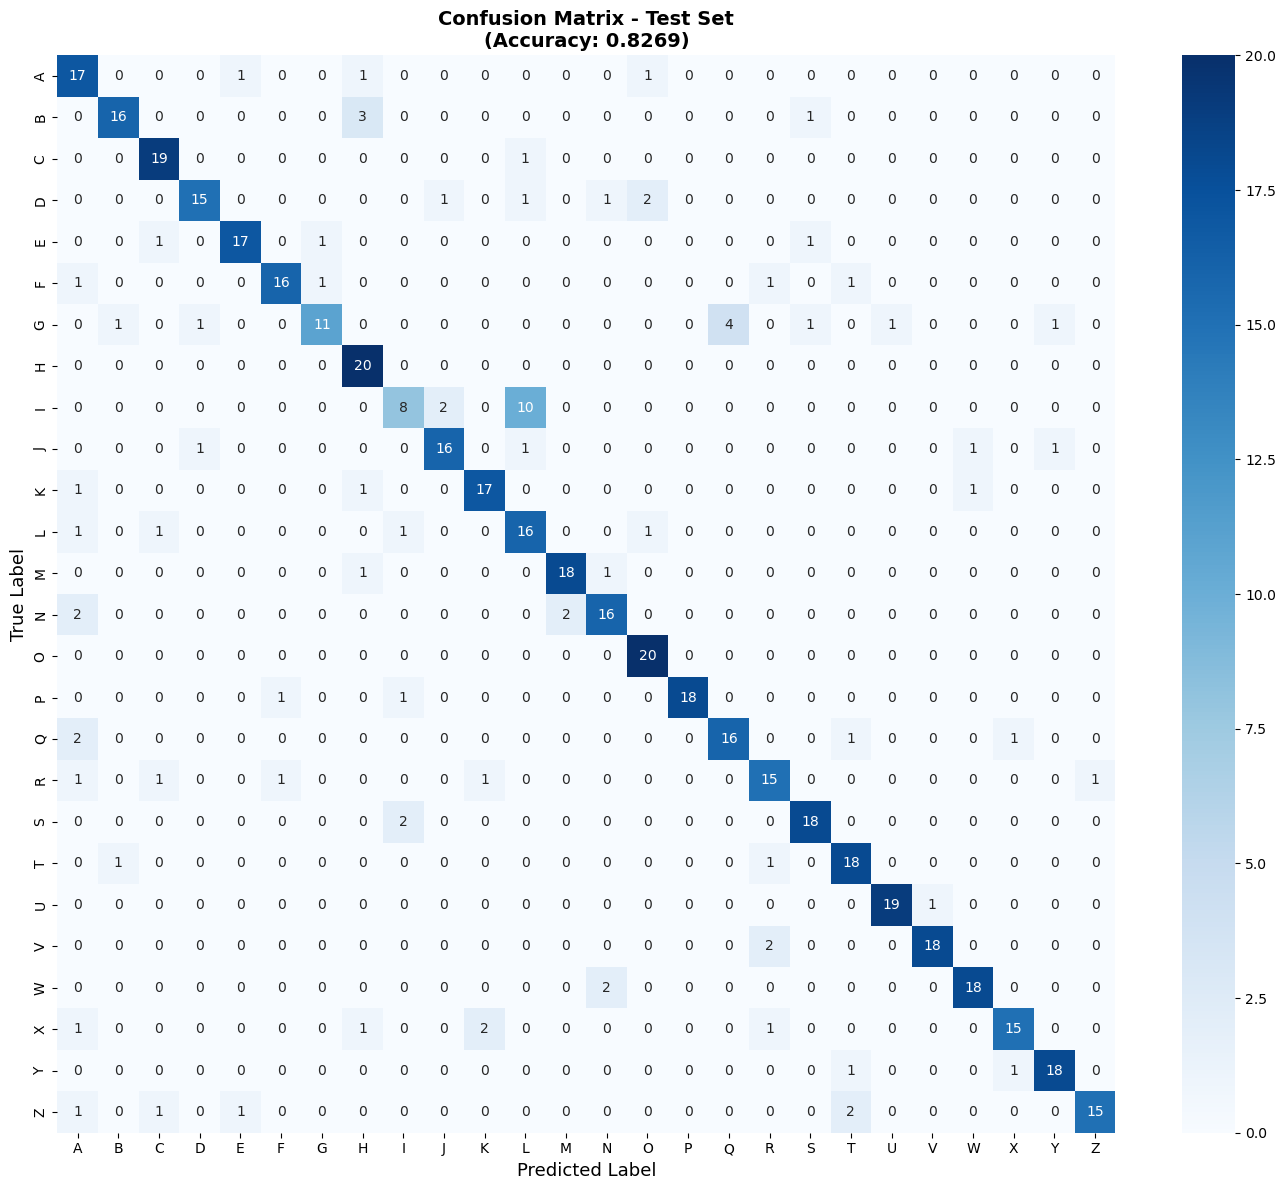

 Confusion matrix disimpan: confusion_matrix.png


In [31]:
# ============================================================
# 4.2 Confusion Matrix
# ============================================================
cm = confusion_matrix(y_test, y_test_pred, labels=sorted(set(y_labels)))

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=sorted(set(y_labels)),
    yticklabels=sorted(set(y_labels)),
    ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=13)
ax.set_ylabel('True Label',      fontsize=13)
ax.set_title(f'Confusion Matrix - Test Set\n(Accuracy: {test_acc:.4f})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Confusion matrix disimpan: confusion_matrix.png')

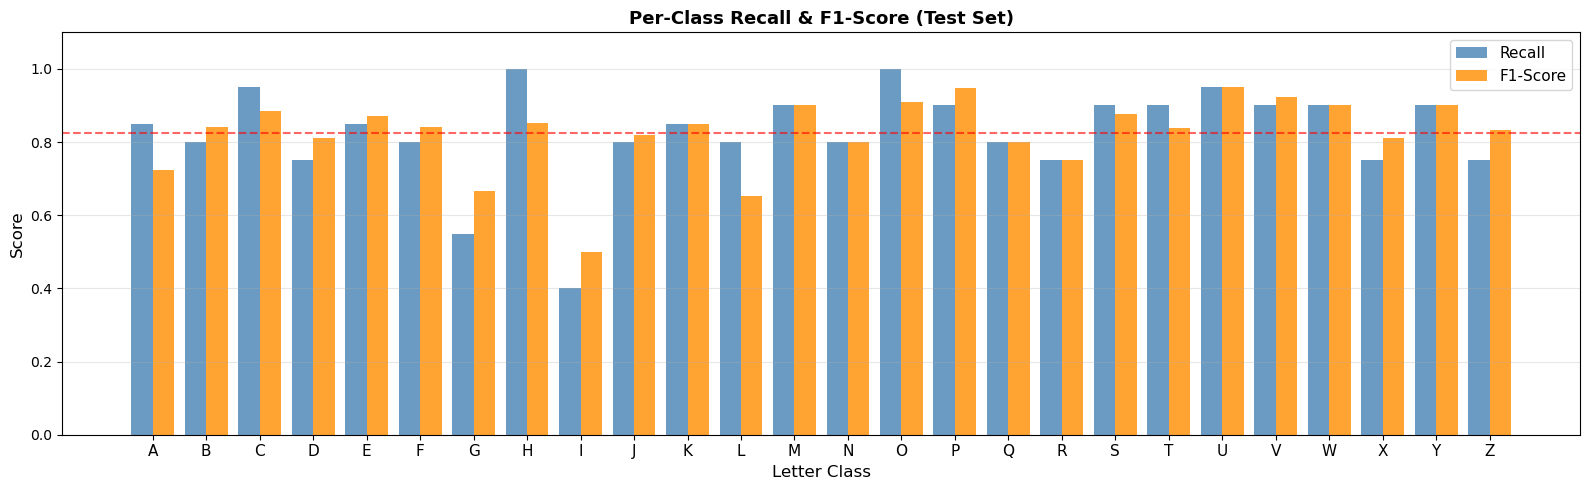

 Per-class performance chart disimpan: per_class_performance.png


In [32]:
# ============================================================
# 4.3 Per-class performance bar chart
# ============================================================
report_dict = classification_report(
    y_test, y_test_pred, output_dict=True, zero_division=0
)

letters = sorted(set(y_labels))
f1_per_class  = [report_dict[l]['f1-score']  for l in letters]
acc_per_class = [report_dict[l]['recall']     for l in letters]  # recall ≈ per-class accuracy

x = np.arange(len(letters))
width = 0.4

fig, ax = plt.subplots(figsize=(16, 5))
bars1 = ax.bar(x - width/2, acc_per_class, width, label='Recall',   color='steelblue',  alpha=0.8)
bars2 = ax.bar(x + width/2, f1_per_class,  width, label='F1-Score', color='darkorange', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(letters, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_xlabel('Letter Class', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Per-Class Recall & F1-Score (Test Set)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(y=test_f1, color='red', linestyle='--', alpha=0.6, label=f'Avg F1={test_f1:.3f}')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('per_class_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Per-class performance chart disimpan: per_class_performance.png')

Prediksi BENAR : 430/520 (82.7%)
Prediksi SALAH : 90/520 (17.3%)


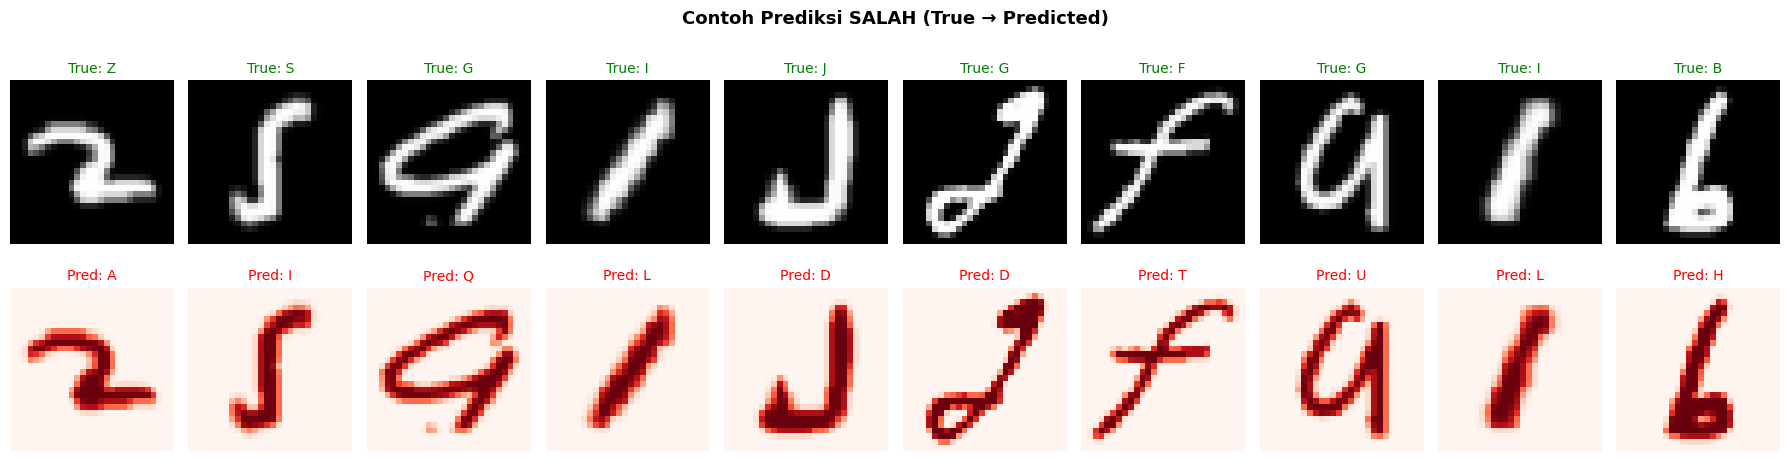

In [33]:
# ============================================================
# 4.4 Visualisasi prediksi benar vs salah
# ============================================================
wrong_idx = np.where(y_test_pred != y_test)[0]
right_idx = np.where(y_test_pred == y_test)[0]

print(f'Prediksi BENAR : {len(right_idx)}/{len(y_test)} ({len(right_idx)/len(y_test)*100:.1f}%)')
print(f'Prediksi SALAH : {len(wrong_idx)}/{len(y_test)} ({len(wrong_idx)/len(y_test)*100:.1f}%)')

# Tampilkan beberapa contoh yang salah
n_show = min(10, len(wrong_idx))
fig, axes = plt.subplots(2, n_show, figsize=(18, 5))
fig.suptitle('Contoh Prediksi SALAH (True → Predicted)', fontsize=13, fontweight='bold')

for i, idx in enumerate(wrong_idx[:n_show]):
    img = np.transpose(X_test_img[idx])
    axes[0][i].imshow(img, cmap='gray')
    axes[0][i].set_title(f'True: {y_test[idx]}', color='green', fontsize=10)
    axes[0][i].axis('off')
    
    axes[1][i].imshow(img, cmap='Reds')
    axes[1][i].set_title(f'Pred: {y_test_pred[idx]}', color='red', fontsize=10)
    axes[1][i].axis('off')

plt.tight_layout()
plt.savefig('wrong_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
# ============================================================
# 4.5 Ringkasan Akhir
# ============================================================
print('='*60)
print(' RINGKASAN PROYEK')
print('='*60)
print(f"Dataset       : EMNIST Letters (26 kelas A-Z)")
print(f"Total sampel  : {TOTAL_SAMPLES} ({SAMPLES_PER_CLASS} per kelas)")
print(f"Train/Test    : 80% / 20% (stratified)")
print()
print(f"HOG Parameters:")
print(f"  orientations    = {HOG_PARAMS['orientations']}")
print(f"  pixels_per_cell = {HOG_PARAMS['pixels_per_cell']}")
print(f"  cells_per_block = {HOG_PARAMS['cells_per_block']}")
print(f"  Feature dim     = {X_train_hog.shape[1]}")
print()
print(f"SVM Best Parameters: {grid_search.best_params_}")
print()
print(f"PERFORMANCE METRICS:")
print(f"  Training Accuracy : {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"  Test Accuracy     : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  Test Precision    : {test_prec:.4f}")
print(f"  Test Recall       : {test_rec:.4f}")
print(f"  Test F1-Score     : {test_f1:.4f}")
print('='*60)

 RINGKASAN PROYEK
Dataset       : EMNIST Letters (26 kelas A-Z)
Total sampel  : 2600 (100 per kelas)
Train/Test    : 80% / 20% (stratified)

HOG Parameters:
  orientations    = 9
  pixels_per_cell = (4, 4)
  cells_per_block = (2, 2)
  Feature dim     = 1296

SVM Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

PERFORMANCE METRICS:
  Training Accuracy : 1.0000 (100.00%)
  Test Accuracy     : 0.8269  (82.69%)
  Test Precision    : 0.8365
  Test Recall       : 0.8269
  Test F1-Score     : 0.8252
